In [1]:
import numpy as np
import gc
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

**Load raw MERFISH data**

In [2]:
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850-raw-wmeta-ccf.h5ad'
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 3739961 × 550
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol', 'transcript_identifier'
    uns: 'accessed_on', 'src'

In [3]:
isoctx_ad = adata[adata.obs['parcellation_division'] == 'Isocortex'].copy()
isoctx_ad

AnnData object with n_obs × n_vars = 935742 × 550
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol', 'transcript_identifier'
    uns: 'accessed_on', 'src'

In [4]:
# Count the number of cells in each class
class_counts = isoctx_ad.obs["class"].value_counts()
class_counts

class
01 IT-ET Glut        440869
02 NP-CT-L6b Glut    131332
33 Vascular          104577
30 Astro-Epen        103636
07 CTX-MGE GABA       56559
31 OPC-Oligo          54816
06 CTX-CGE GABA       26308
34 Immune             15198
08 CNU-MGE GABA         847
20 MB GABA              410
05 OB-IMN GABA          350
19 MB Glut              233
09 CNU-LGE GABA         224
13 CNU-HYa Glut         175
03 OB-CR Glut           133
11 CNU-HYa GABA          33
04 DG-IMN Glut           15
32 OEC                   14
29 CB Glut                5
10 LSX GABA               4
28 CB GABA                3
26 P GABA                 1
Name: count, dtype: int64

In [5]:
# Identify classes with few cells
n_cells_threshold = 340

# Filter out the cells belonging to the identified classes
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
classes_to_remove.append("20 MB GABA")
isoctx_ad = isoctx_ad[~isoctx_ad.obs["class"].isin(classes_to_remove)].copy()

In [6]:
# division_mask = adata.obs['parcellation_division'] == 'Isocortex'
# section_mask = adata.obs['brain_section_label'] == 'C57BL6J-638850.38'
# pred_iso = division_mask & section_mask
# isocortex_ad = adata[pred_iso].copy()

In [6]:
del adata
gc.collect()

400

**Loading modules dataframe**

In [7]:
# Loading Modules dataframe
select_region = "Isocortex-1"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
ENSMUSG00000015090,ENSMUSG00000015090,Isocortex-M1,yellow,0.645442,-0.082131,0.055263,0.123491,-0.087391,0.096088,0.129945,0.244009,0.606363,-0.205105
ENSMUSG00000031425,ENSMUSG00000031425,Isocortex-M1,yellow,0.919267,-0.107151,0.070567,0.095239,-0.112462,0.107643,0.243849,0.051845,0.041710,-0.244151
ENSMUSG00000115529,ENSMUSG00000115529,Isocortex-M1,yellow,0.290416,-0.025055,0.009020,0.027299,-0.029463,0.038628,0.236592,0.012456,0.003026,-0.099603
ENSMUSG00000029819,ENSMUSG00000029819,Isocortex-M2,turquoise,-0.003594,0.542115,0.002021,-0.003075,-0.085746,-0.004960,0.046668,0.012330,0.004241,-0.161405
ENSMUSG00000024610,ENSMUSG00000024610,Isocortex-M3,blue,0.006335,-0.033054,0.153545,0.040280,-0.027896,0.001917,-0.002614,0.018507,0.042056,-0.035275


In [8]:
# Renaming the modules
module_names = {
    "Isocortex-M1": "Oligodendrocyte Myelination",
    "Isocortex-M2": "Neuronal Projection",
    "Isocortex-M3": "Immune Response",
    "Isocortex-M4": "Vascular Morphogenesis",
    "Isocortex-M5": "Developmental Signaling",
    "Isocortex-M6": "Neural Development",
    "Isocortex-M7": "Structural Morphogenesis",
    "Isocortex-M8": "Extracellular Matrix",
    "Isocortex-M9": "Axon Guidance",
}

In [9]:
# Rename the 'module' column in modules_df using module_names and save as a new dataframe
modules_df_renamed = modules_df.copy()
modules_df_renamed["module"] = modules_df_renamed["module"].map(module_names).fillna(modules_df_renamed["module"])
modules_df_renamed.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
ENSMUSG00000015090,ENSMUSG00000015090,Oligodendrocyte Myelination,yellow,0.645442,-0.082131,0.055263,0.123491,-0.087391,0.096088,0.129945,0.244009,0.606363,-0.205105
ENSMUSG00000031425,ENSMUSG00000031425,Oligodendrocyte Myelination,yellow,0.919267,-0.107151,0.070567,0.095239,-0.112462,0.107643,0.243849,0.051845,0.041710,-0.244151
ENSMUSG00000115529,ENSMUSG00000115529,Oligodendrocyte Myelination,yellow,0.290416,-0.025055,0.009020,0.027299,-0.029463,0.038628,0.236592,0.012456,0.003026,-0.099603
ENSMUSG00000029819,ENSMUSG00000029819,Neuronal Projection,turquoise,-0.003594,0.542115,0.002021,-0.003075,-0.085746,-0.004960,0.046668,0.012330,0.004241,-0.161405
ENSMUSG00000024610,ENSMUSG00000024610,Immune Response,blue,0.006335,-0.033054,0.153545,0.040280,-0.027896,0.001917,-0.002614,0.018507,0.042056,-0.035275


**Computing all MEs**

In [10]:
from sklearn.decomposition import PCA

# Preprocess the data
sc.pp.normalize_total(isoctx_ad, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(isoctx_ad)  # Log-transform the data
sc.pp.scale(isoctx_ad)  # Scale the data

# Group genes by module
module_gene_dict = modules_df_renamed.groupby("module")["gene_name"].apply(list).to_dict()

# Prepare a DataFrame to store eigengenes
eigengenes_isoctx = pd.DataFrame(index=isoctx_ad.obs_names)

for module, genes in module_gene_dict.items():
    # Filter genes present in isoctx_ad
    genes_in_isoctx = [g for g in genes if g in isoctx_ad.var_names]
    if len(genes_in_isoctx) < 2:
        continue  # Need at least 2 genes for PCA

    # Extract expression matrix for the module
    X = isoctx_ad[:, genes_in_isoctx].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()  # Convert sparse to dense if needed

    # Compute first principal component (eigengene)
    pca = PCA(n_components=1)
    eigengene = pca.fit_transform(X).flatten()
    eigengenes_isoctx[module] = eigengene

eigengenes_isoctx.head()

,Axon Guidance,Developmental Signaling,Extracellular Matrix,Immune Response,Neural Development,Neuronal Projection,Oligodendrocyte Myelination,Structural Morphogenesis,Vascular Morphogenesis
cell_label,,,,,,,,,
1018093344102150034-1,-4.521385,-0.130943,-0.152974,8.466016,-1.048799,-1.411738,-1.600457,-1.330896,0.045029
1018093344102150078-3,-5.587750,2.484602,0.159833,6.172529,-0.755777,-5.253535,-1.537631,-1.330896,-0.474037
1018093344102010421-4,-4.668220,-0.341942,-1.159566,8.625017,-0.744384,-4.995938,-1.432405,-0.251885,3.597567
1018093344102160408-2,-5.381592,2.499006,1.908359,10.189806,-0.101353,-3.353712,-1.830213,-1.330896,-0.180555
1018093344101870301-2,-5.300714,0.441520,-0.092421,6.879589,-0.959228,-3.492902,-2.237197,-1.330896,0.089217


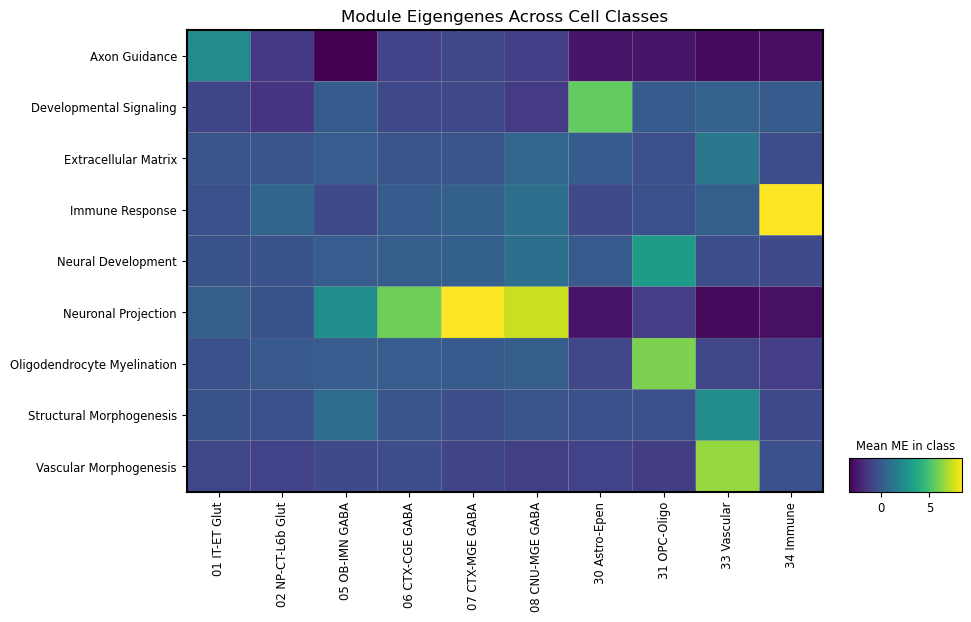

In [11]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(eigengenes_isoctx)
adata_vis.obs["class"] = isoctx_ad.obs["class"]  # Add cell type labels

# Matrixplot
sc.pl.matrixplot(
    adata_vis,
    var_names=eigengenes_isoctx.columns,
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Mean ME in class",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

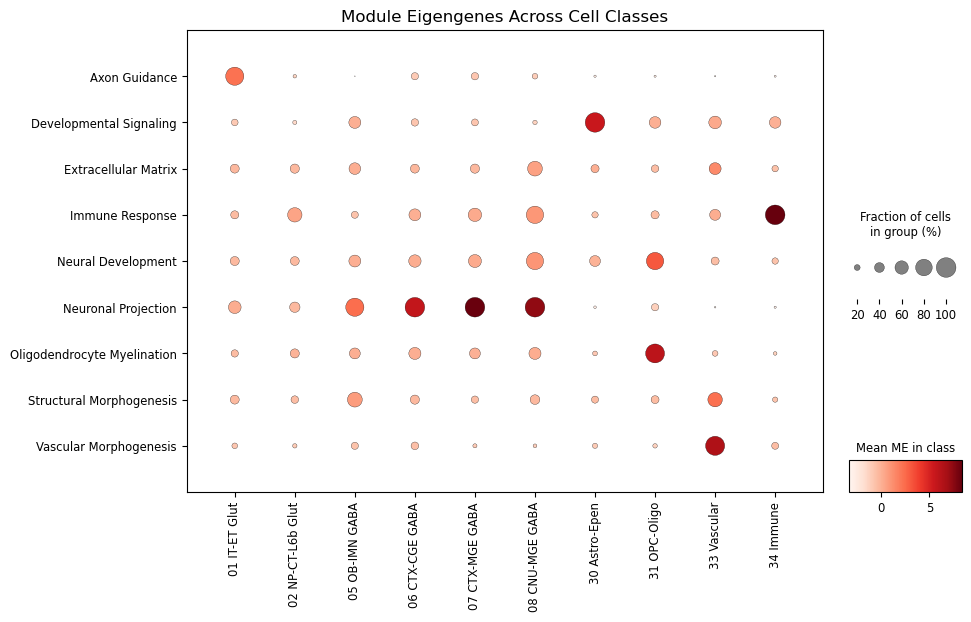

In [13]:
# Matrixplot
sc.pl.dotplot(
    adata_vis,
    var_names=eigengenes_isoctx.columns,
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Mean ME in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

In [15]:
# Adding MEs to AnnData object
merged_df = pd.merge(isoctx_ad.obs, eigengenes_isoctx, left_index=True, right_index=True)
merged_df.head()

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,...,parcellation_substructure_color,Axon Guidance,Developmental Signaling,Extracellular Matrix,Immune Response,Neural Development,Neuronal Projection,Oligodendrocyte Myelination,Structural Morphogenesis,Vascular Morphogenesis
cell_label,,,,,,,,,,,,,,,,,,,,,
1018093344102150034-1,C57BL6J-638850.18,5283,0.592576,C57BL6J-638850,C57BL6J-638850,wt/wt,M,2.122639,4.240894,3.4,...,#08858C,-4.521385,-0.130943,-0.152974,8.466016,-1.048799,-1.411738,-1.600457,-1.330896,0.045029
1018093344102150078-3,C57BL6J-638850.18,5283,0.567537,C57BL6J-638850,C57BL6J-638850,wt/wt,M,2.133733,4.052824,3.4,...,#08858C,-5.587750,2.484602,0.159833,6.172529,-0.755777,-5.253535,-1.537631,-1.330896,-0.474037
1018093344102010421-4,C57BL6J-638850.18,5283,0.625780,C57BL6J-638850,C57BL6J-638850,wt/wt,M,2.186353,4.187762,3.4,...,#08858C,-4.668220,-0.341942,-1.159566,8.625017,-0.744384,-4.995938,-1.432405,-0.251885,3.597567
1018093344102160408-2,C57BL6J-638850.18,5283,0.673605,C57BL6J-638850,C57BL6J-638850,wt/wt,M,1.656049,4.574030,3.4,...,#08858C,-5.381592,2.499006,1.908359,10.189806,-0.101353,-3.353712,-1.830213,-1.330896,-0.180555
1018093344101870301-2,C57BL6J-638850.18,5283,0.511515,C57BL6J-638850,C57BL6J-638850,wt/wt,M,2.845072,4.226426,3.4,...,#08858C,-5.300714,0.441520,-0.092421,6.879589,-0.959228,-3.492902,-2.237197,-1.330896,0.089217


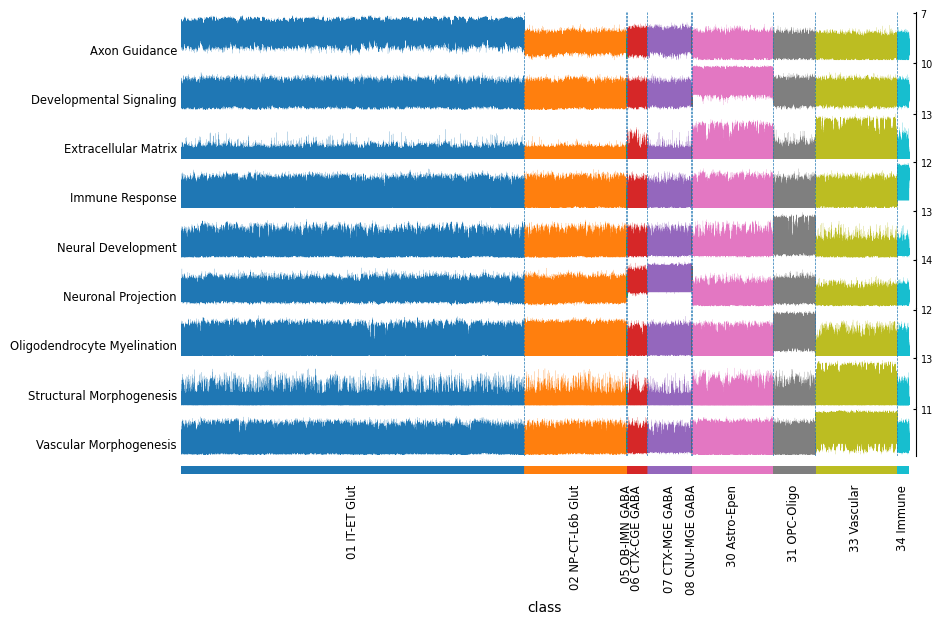

In [16]:
# Add all module eigengenes to AnnData and class labels
all_modules = [col for col in merged_df.columns if col in module_gene_dict.keys()]
adata_tracks = sc.AnnData(merged_df[all_modules])
adata_tracks.obs["class"] = merged_df["class"].astype("category")  # Ensure categorical dtype

# Plot tracksplot of module eigengenes across cell classes
sc.pl.tracksplot(
    adata_tracks,
    var_names=all_modules,
    groupby="class",
    figsize=(10, 6),
    dendrogram=False,
    title="Tracksplot of Module Eigengenes Across Cell Classes",
    cmap="viridis"
)

In [17]:
# Compute correlation of each gene in isoctx_ad with all module eigengenes
gene_eigengene_corr = pd.DataFrame(index=isoctx_ad.var_names, columns=eigengenes_isoctx.columns)

# Convert X to dense if needed
X_dense = isoctx_ad.X.toarray() if not isinstance(isoctx_ad.X, np.ndarray) else isoctx_ad.X

for module in eigengenes_isoctx.columns:
    # Get eigengene vector for all cells
    eigengene_vec = eigengenes_isoctx[module].values
    # Compute correlation for each gene
    corrs = np.array([
        np.corrcoef(X_dense[:, i], eigengene_vec)[0, 1]
        for i in range(X_dense.shape[1])
    ])
    gene_eigengene_corr[module] = corrs

gene_eigengene_corr.head()

,Axon Guidance,Developmental Signaling,Extracellular Matrix,Immune Response,Neural Development,Neuronal Projection,Oligodendrocyte Myelination,Structural Morphogenesis,Vascular Morphogenesis
gene_identifier,,,,,,,,,
ENSMUSG00000026778,-0.134866,-0.004677,-0.054825,0.010125,0.501885,0.044635,0.557583,-0.037867,-0.083760
ENSMUSG00000026837,0.171401,-0.166974,0.158299,0.031113,-0.048808,0.042574,-0.055626,0.028636,-0.126159
ENSMUSG00000001985,-0.079489,-0.238811,-0.141585,0.083604,0.112243,0.270804,0.093303,-0.137616,-0.186334
ENSMUSG00000039323,-0.054939,0.462713,0.271024,0.002492,0.055782,-0.112617,-0.062005,0.151209,0.090732
ENSMUSG00000048387,0.047846,0.016930,0.299205,0.041814,0.036301,0.047281,0.011482,0.136124,-0.012851


In [18]:
# Map gene identifiers in gene_eigengene_corr to gene symbols using isoctx_ad.var
gene_id_to_symbol = isoctx_ad.var['gene_symbol'].to_dict()
gene_eigengene_corr = gene_eigengene_corr.rename(index=gene_id_to_symbol)
gene_eigengene_corr.head()

,Axon Guidance,Developmental Signaling,Extracellular Matrix,Immune Response,Neural Development,Neuronal Projection,Oligodendrocyte Myelination,Structural Morphogenesis,Vascular Morphogenesis
gene_identifier,,,,,,,,,
Prkcq,-0.134866,-0.004677,-0.054825,0.010125,0.501885,0.044635,0.557583,-0.037867,-0.083760
Col5a1,0.171401,-0.166974,0.158299,0.031113,-0.048808,0.042574,-0.055626,0.028636,-0.126159
Grik3,-0.079489,-0.238811,-0.141585,0.083604,0.112243,0.270804,0.093303,-0.137616,-0.186334
Igfbp2,-0.054939,0.462713,0.271024,0.002492,0.055782,-0.112617,-0.062005,0.151209,0.090732
Osr1,0.047846,0.016930,0.299205,0.041814,0.036301,0.047281,0.011482,0.136124,-0.012851


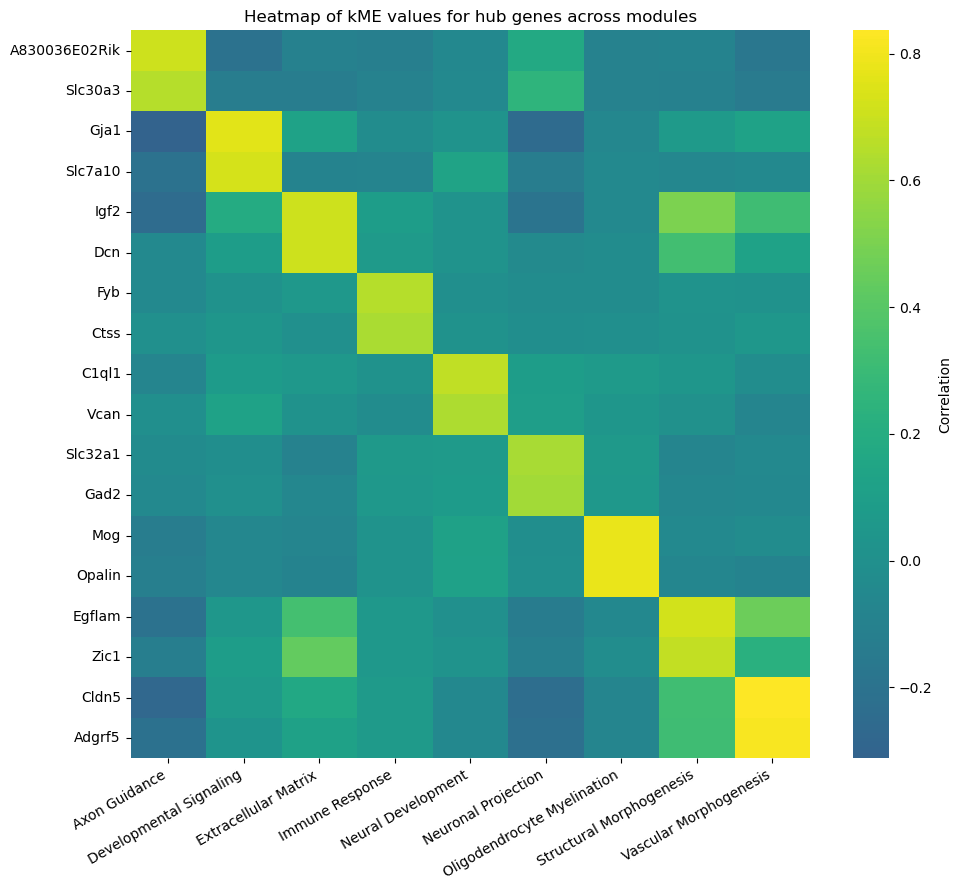

In [19]:
from collections import OrderedDict
import seaborn as sns

# For each module, get the top 2 genes by absolute correlation
top_genes = []
for module in gene_eigengene_corr.columns:
    top2 = gene_eigengene_corr[module].abs().nlargest(2).index.tolist()
    top_genes.extend(top2)

# Remove duplicates while preserving order
top_genes_unique = list(OrderedDict.fromkeys(top_genes))

# Subset the correlation matrix
heatmap_data = gene_eigengene_corr.loc[top_genes_unique]

# Plot heatmap
plt.figure(figsize=(10, max(4, 0.5 * len(top_genes_unique))))
sns.heatmap(heatmap_data, annot=None, cmap="viridis", center=0, cbar_kws={'label': 'Correlation'})
plt.title("Heatmap of kME values for hub genes across modules")
plt.xticks(rotation=30, ha="right")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [20]:
def plot_module_eigengene_scatter(module, z_section, adata=isoctx_ad, eigengenes_df=eigengenes_isoctx, x_col='x_reconstructed', y_col='y_reconstructed', cmap='viridis', fig_width=8, fig_height=6):
    # Subset AnnData to the given z section
    mask = adata.obs['brain_section_label'] == z_section
    adata_z = adata[mask]
    # Get cell labels for this subset
    cell_labels = adata_z.obs_names
    # Get eigengene values for the selected module and cells
    eigengene_vals = eigengenes_df.loc[cell_labels, module]
    # Get spatial coordinates
    x = adata_z.obs[x_col]
    y = adata_z.obs[y_col]
    # Plot
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sc = ax.scatter(x, y, c=eigengene_vals, cmap=cmap, s=0.5, marker='.')
    cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label(f"{module} eigengene")
    ax.set_title(f"{module} eigengene")
    # ax.set_xlabel(x_col)
    # ax.set_ylabel(y_col)
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    return fig, ax

(<Figure size 400x300 with 2 Axes>,
 <Axes: title={'center': 'Axon Guidance eigengene'}>)

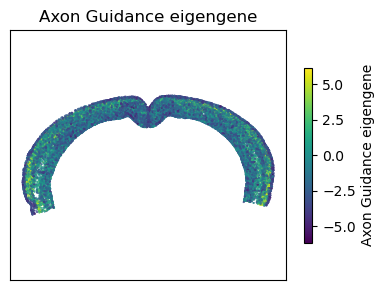

In [23]:
plot_module_eigengene_scatter(
    module = "Axon Guidance",
    z_section = 'C57BL6J-638850.38',
    adata=isoctx_ad,
    eigengenes_df=eigengenes_isoctx,
    x_col='x_reconstructed',
    y_col='y_reconstructed',
    cmap='viridis',
    fig_width=4,
    fig_height=3
    )

In [27]:
import math

def plot_multiple_module_eigengene_scatters(
    modules,
    z_section,
    adata=isoctx_ad,
    eigengenes_df=eigengenes_isoctx,
    x_col='x_reconstructed',
    y_col='y_reconstructed',
    cmap='viridis',
    fig_width=4,
    fig_height=3,
    ncols=4,
    suptitle=None
):
    """
    Plot scatter plots of module eigengenes for multiple modules in a given z_section.

    Args:
        modules (list): List of module names to plot.
        z_section (str): Section label to subset.
        adata (AnnData): AnnData object.
        eigengenes_df (pd.DataFrame): DataFrame of eigengenes.
        x_col (str): Column name for x coordinates.
        y_col (str): Column name for y coordinates.
        cmap (str): Colormap.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        ncols (int): Number of columns in the subplot grid.
        suptitle (str): Optional super-title for the figure.

    Returns:
        fig, axes: Matplotlib figure and axes array.
    """

    n = len(modules)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width * ncols, fig_height * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, module in enumerate(modules):
        mask = adata.obs['brain_section_label'] == z_section
        adata_z = adata[mask]
        cell_labels = adata_z.obs_names
        eigengene_vals = eigengenes_df.loc[cell_labels, module]
        x = adata_z.obs[x_col]
        y = adata_z.obs[y_col]
        sc = axes[i].scatter(x, y, c=eigengene_vals, cmap=cmap, s=0.5, marker='.')
        cbar = plt.colorbar(sc, ax=axes[i], shrink=0.7)
        cbar.set_label(f"Eigengene expression")
        axes[i].set_title(module)
        axes[i].set_ylim(11, 0)
        axes[i].set_xlim(0, 11)
        axes[i].axis('equal')
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    return fig, axes

(<Figure size 1600x300 with 8 Axes>,
 array([<Axes: title={'center': 'Immune Response'}>,
        <Axes: title={'center': 'Oligodendrocyte Myelination'}>,
        <Axes: title={'center': 'Developmental Signaling'}>,
        <Axes: title={'center': 'Neuronal Projection'}>], dtype=object))

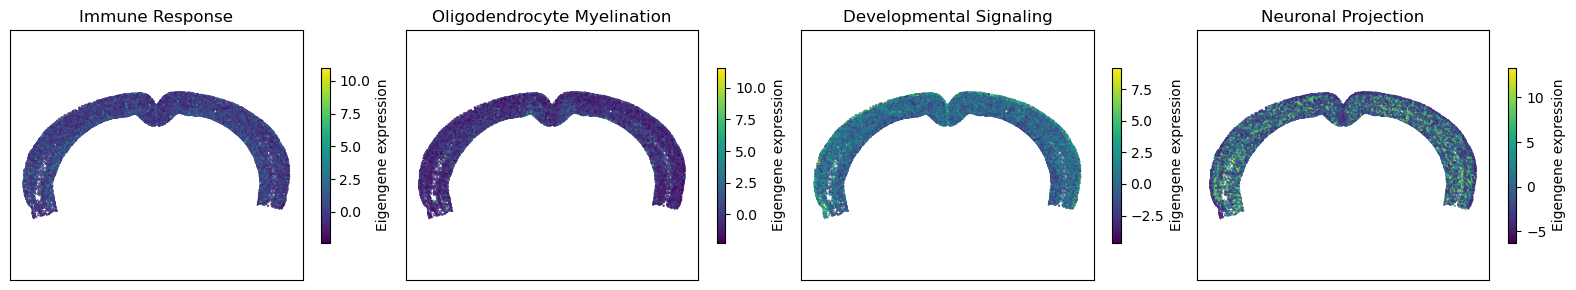

In [28]:
plot_multiple_module_eigengene_scatters(
    modules = ["Immune Response", "Oligodendrocyte Myelination", "Developmental Signaling", "Neuronal Projection"],
    z_section = 'C57BL6J-638850.38',
    adata=isoctx_ad,
    eigengenes_df=eigengenes_isoctx,
    x_col='x_reconstructed',
    y_col='y_reconstructed',
    cmap='viridis',
    fig_width=4,
    fig_height=3
)

**Plotting the modules**

In [24]:
select_module = "Immune Response"

In [25]:
def plot_ME(xx, yy, cc=None, val=None, adata=None, pc_component=None, fig_width=8, fig_height=8, cmap=None, cbar_label=None, title=None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    scatter_plot = None  # To hold the scatter plot object
    
    # PCA component coloring
    if pc_component is not None:
        if adata is None:
            raise ValueError("adata must be provided when using pc_component.")
        val = adata.obsm['X_pca'][:, pc_component]
        cmap = cmap or 'viridis'
        scatter_plot = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar_label = cbar_label or f'ME expression'
        
    # Regular colormap coloring
    elif cmap is not None:
        scatter_plot = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar_label = cbar_label or 'Value'  # Default label
        
    # Categorical color list
    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, color=cc, marker='.')
        
    # Default to black
    else:
        ax.scatter(xx, yy, s=0.5, color='k', marker='.')
    
    # Add color bar if needed
    if scatter_plot is not None:
        cbar = fig.colorbar(scatter_plot, ax=ax, shrink=0.6, aspect=10)
        if cbar_label:
            cbar.set_label(cbar_label, rotation=270, labelpad=15)
    
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')

    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title(f"Module eigengene for {select_module}")
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

**Raw module eigengenes**

In [26]:
select_genes = modules_df_renamed[modules_df_renamed["module"] == select_module].index
common_genes = isoctx_ad.var_names.intersection(select_genes)
print(f"{len(common_genes)} found in the panel from {select_genes.shape[0]} genes in the module")

iso_subset = isoctx_ad[:,common_genes].copy()
# sc.pp.filter_cells(adata_subset, min_genes=1)
sc.pp.normalize_total(iso_subset, target_sum=1e4)
sc.pp.log1p(iso_subset)
sc.pp.scale(iso_subset, max_value=10)
sc.tl.pca(iso_subset, n_comps = 1, svd_solver="arpack")

16 found in the panel from 239 genes in the module


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [27]:
# Taking a z section for plotting purposes
isoctx_z = iso_subset[iso_subset.obs['brain_section_label'] == 'C57BL6J-638850.38']

(<Figure size 800x500 with 2 Axes>, <Axes: >)

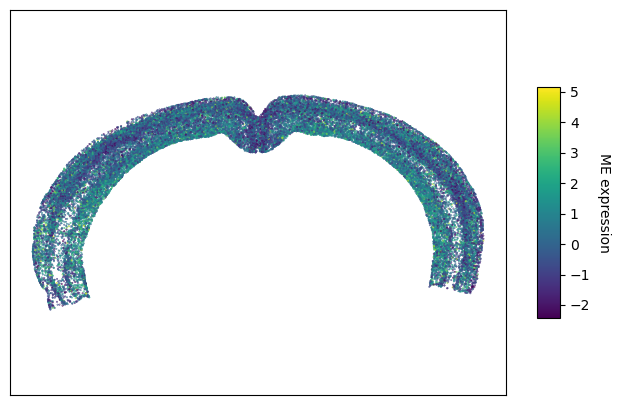

In [28]:
plot_ME(
    isoctx_z.obs['x_reconstructed'],
    isoctx_z.obs['y_reconstructed'],
    adata=isoctx_z,
    pc_component=0,
    cmap='viridis',
    fig_height=5,
    title=f"")

**Imputed module eigengenes**

In [29]:
select_genes = modules_df_renamed[modules_df_renamed["module"] == select_module].index
common_genes_imp = isoctx_ad_imp.var_names.intersection(select_genes)
print(f"{len(common_genes_imp)} found in the panel from {select_genes.shape[0]} genes in the module")

iso_subset_imp = isoctx_ad_imp[:,common_genes_imp].copy()
# sc.pp.filter_cells(adata_subset, min_genes=1)
# sc.pp.normalize_total(iso_subset, target_sum=1e4)
# sc.pp.log1p(iso_subset)
# sc.pp.scale(iso_subset, max_value=10)
sc.tl.pca(iso_subset_imp, n_comps = 1, svd_solver="arpack")

189 found in the panel from 239 genes in the module


In [30]:
# Taking a section for plotting purposes
isoctx_z_imp = iso_subset_imp[iso_subset_imp.obs['brain_section_label'] == 'C57BL6J-638850.38']

(<Figure size 800x500 with 2 Axes>, <Axes: >)

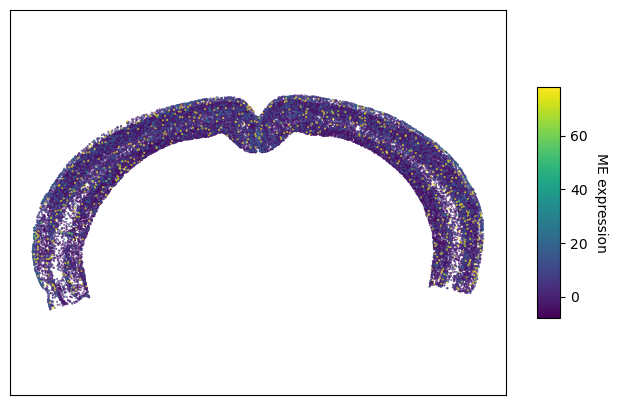

In [31]:
plot_ME(
    isoctx_z_imp.obs['x_reconstructed'],
    isoctx_z_imp.obs['y_reconstructed'],
    adata=isoctx_z_imp,
    pc_component=0,
    cmap='viridis',
    fig_height=5,
    title=f"",)

**Module specificity**

In [32]:
def module_tau(iso_subset, select_module, group_by='class'):
    # Shift the eigengene values to ensure non-negativity
    tau_df = iso_subset.obs[[group_by]].copy()
    tau_df[select_module] = iso_subset.obsm['X_pca'][:,0]
    tau_df[select_module] = tau_df[select_module] - tau_df[select_module].min() + 1e-6

    # Compute average eigengene per cell class
    avg_expression = tau_df.groupby(group_by, observed=False)[select_module].mean()

    # Normalize by the maximum average expression
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr

    # Compute tau score
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    return tau

In [33]:
module_tau(iso_subset, select_module, group_by='class')

np.float32(0.6371943)

In [34]:
module_tau(iso_subset_imp, select_module, group_by='class')

np.float32(0.9086163)

**All module eigengenes**

In [ ]:
from sklearn.decomposition import PCA

# Preprocess the data
sc.pp.normalize_total(isoctx_ad, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(isoctx_ad)  # Log-transform the data
sc.pp.scale(isoctx_ad)  # Scale the data

# Group genes by module
module_gene_dict = modules_df_renamed.groupby("module")["gene_name"].apply(list).to_dict()

# Prepare a DataFrame to store eigengenes
eigengenes_isoctx = pd.DataFrame(index=isoctx_ad.obs_names)

for module, genes in module_gene_dict.items():
    # Filter genes present in isoctx_ad
    genes_in_isoctx = [g for g in genes if g in isoctx_ad.var_names]
    if len(genes_in_isoctx) < 2:
        continue  # Need at least 2 genes for PCA

    # Extract expression matrix for the module
    X = isoctx_ad[:, genes_in_isoctx].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()  # Convert sparse to dense if needed

    # Compute first principal component (eigengene)
    pca = PCA(n_components=1)
    eigengene = pca.fit_transform(X).flatten()
    eigengenes_isoctx[module] = eigengene

eigengenes_isoctx.head()

,Axon Guidance,Developmental Signaling,Extracellular Matrix,Immune Response,Neural Development,Neuronal Projection,Oligodendrocyte Myelination,Structural Morphogenesis,Vascular Morphogenesis
cell_label,,,,,,,,,
1018093344102150014,-2.967045,2.292018,0.462946,0.257125,-0.781457,-0.955275,-0.356748,0.421324,0.033015
1018093344101870351-2,-3.916389,-1.448527,-1.160178,-0.070605,-0.327177,-2.632686,-1.750546,1.321350,-0.780348
1018093344101870458-3,-2.579811,-0.178351,0.253217,0.597391,-0.051839,2.213902,2.171401,-1.331059,-0.546186
1018093344102150034-1,-4.519760,-0.130684,-0.153256,8.447230,-1.049289,-1.414873,-1.600377,-1.331059,0.044388
1018093344102150078-3,-5.586183,2.483761,0.159654,6.178561,-0.755932,-5.255055,-1.537252,-1.331059,-0.472562


**Heatmap**

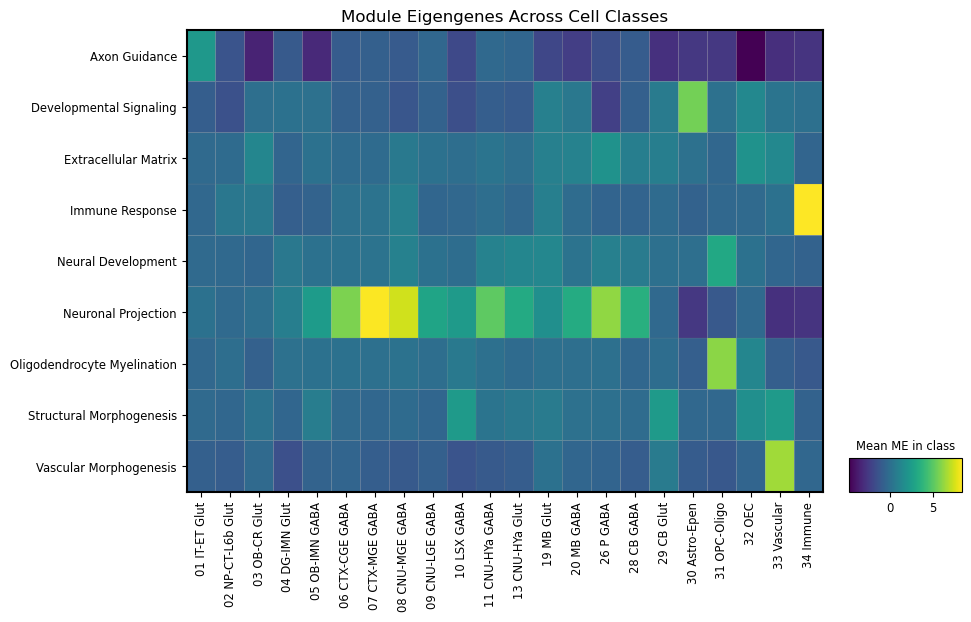

In [39]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(eigengenes_isoctx)
adata_vis.obs["class"] = isoctx_ad.obs["class"]  # Add cell type labels

# Matrixplot
sc.pl.matrixplot(
    adata_vis,
    var_names=eigengenes_isoctx.columns,
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Mean ME in class",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

**Load scRNA-seq data**

In [22]:
# Loading AnnData object
select_region = "Isocortex-1"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
sc_adata = sc.read_h5ad(expr_path)
sc_adata

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [23]:
# Preprocess the data
sc.pp.normalize_total(sc_adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(sc_adata)  # Log-transform the data

## Plot cell labels

In [6]:
pred = (adata.obs['brain_section_label'] == 'C57BL6J-638850.38')
section = adata.obs[pred]
print("Number of cells in section:",len(section))

Number of cells in section: 120186


In [16]:
def plot_section(xx, yy, cc = None, val = None, fig_width = 8, fig_height = 8, cmap = None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    if cmap is not None:
        plt.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        plt.scatter(xx, yy, s=0.5, color=cc, marker='.')
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

In [71]:
def plot_section_with_legend(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None, legends=None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if val is not None and cmap is not None:
        sc = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Value")

    elif legends is not None and cc is not None:
        # Ensure pandas Series, drop NaNs
        legends = pd.Series(legends)
        cc = pd.Series(cc)
        valid_mask = legends.notna() & cc.notna()

        xx = xx[valid_mask]
        yy = yy[valid_mask]
        legends = legends[valid_mask]
        cc = cc[valid_mask]

        unique_labels = legends.unique()

        for label in unique_labels:
            mask = legends == label
            color = cc[mask].iloc[0]  # assume consistent color per label
            ax.scatter(xx[mask], yy[mask], s=0.5, marker='.', color=color, label=label)
        ax.legend(markerscale=10, loc = "right", bbox_to_anchor=(1.27, 0.5), fontsize=6)

    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, marker='.', color=cc)

    else:
        ax.scatter(xx, yy, s=0.5, marker='.', color='black')

    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

In [75]:
def plot_gene_expression(adata, gene_symbol, cmap='viridis', fig_width=8, fig_height=8, title=None):
    """
    Plots the expression of a specified gene on the spatial coordinates.

    Args:
        adata: AnnData object containing the spatial transcriptomics data.
        gene_symbol: The gene symbol (string) to plot.
        cmap: Colormap to use for the expression values.
        fig_width: Width of the figure in inches.
        fig_height: Height of the figure in inches.

    Returns:
        The matplotlib figure and axes objects.
    """
    if gene_symbol not in adata.var['gene_symbol'].values:
        raise ValueError(f"Gene symbol '{gene_symbol}' not found in the AnnData object.")

    gene_index = np.where(adata.var['gene_symbol'] == gene_symbol)[0][0]
    gene_expression = adata.X[:, gene_index].toarray().flatten() # Get expression values as a 1D numpy array

    x_coords = adata.obs['x_reconstructed'].values
    y_coords = adata.obs['y_reconstructed'].values

    fig, ax = plot_section(x_coords, y_coords, val=gene_expression, cmap=cmap, fig_width=fig_width, fig_height=fig_height)
    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title(f"Expression of {gene_symbol}")
    cbar = plt.colorbar(ax.collections[0], ax=ax) # Add a colorbar to show expression levels
    cbar.set_label("Expression Level")
    return fig, ax

In [14]:
division_mask = adata.obs['parcellation_division'] == 'Isocortex'
section_mask = adata.obs['brain_section_label'] == 'C57BL6J-638850.38'
pred_iso = division_mask & section_mask
isocortex_ad = adata[pred_iso]

In [ ]:
division_mask = adata_imp.obs['parcellation_division'] == 'Isocortex'
section_mask = adata_imp.obs['brain_section_label'] == 'C57BL6J-638850.38'
pred_iso = division_mask & section_mask
isocortex_ad_imp = adata_imp[pred_iso]

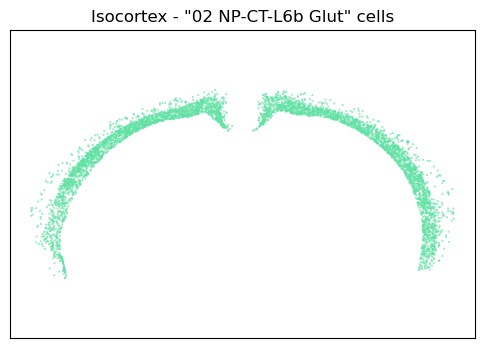

In [77]:
iso_class = isocortex_ad[isocortex_ad.obs['class'] == '02 NP-CT-L6b Glut']
fig, ax = plot_section(iso_class.obs['x_reconstructed'],
                       iso_class.obs['y_reconstructed'],
                       iso_class.obs['class_color'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title("Isocortex - \"02 NP-CT-L6b Glut\" cells")
plt.show()

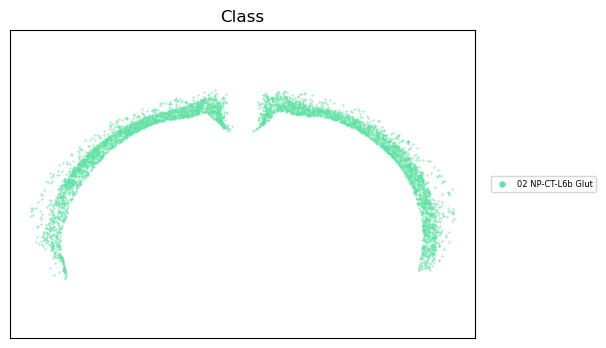

In [73]:
iso_class = isocortex_ad[isocortex_ad.obs['class'] == '02 NP-CT-L6b Glut']
fig, ax = plot_section_with_legend(iso_class.obs['x_reconstructed'],
                       iso_class.obs['y_reconstructed'],
                       iso_class.obs['class_color'],
                       legends=iso_class.obs['class'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title("Class")
plt.show()

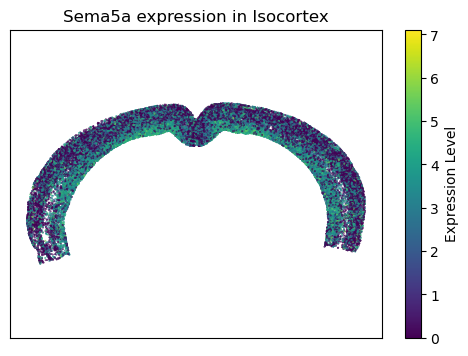

In [78]:
# Example usage:
gene_to_plot = list(overlap_dict['02 NP-CT-L6b Glut'])[0] # Replace with the gene you want to visualize
fig, ax = plot_gene_expression(isocortex_ad,
                               gene_to_plot,
                               fig_width=6,
                               fig_height=4,
                               title=f"{gene_to_plot} expression in Isocortex")
plt.show()

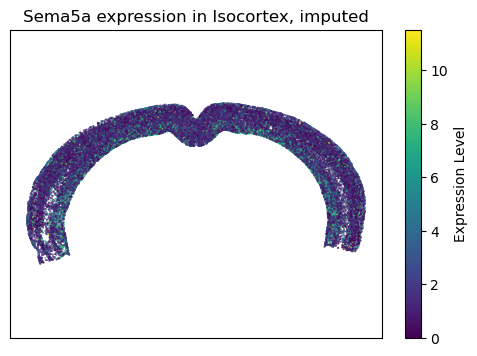

In [79]:
# Example usage:
gene_to_plot = list(overlap_dict['02 NP-CT-L6b Glut'])[0] # Replace with the gene you want to visualize
fig, ax = plot_gene_expression(isocortex_ad_imp,
                               gene_to_plot,
                               fig_width=6,
                               fig_height=4,
                               title=f"{gene_to_plot} expression in Isocortex, imputed")
plt.show()

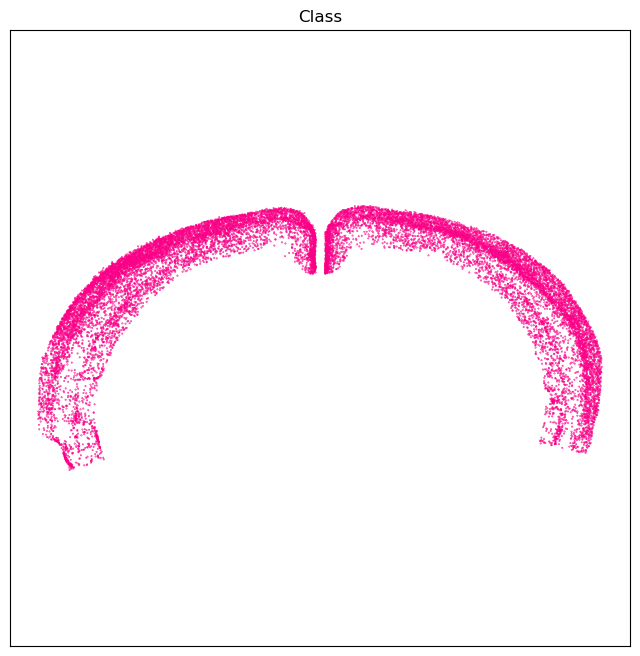

In [57]:
iso_class = isocortex_ad[isocortex_ad.obs['class'] == '01 IT-ET Glut']
fig, ax = plot_section(iso_class.obs['x_reconstructed'], iso_class.obs['y_reconstructed'], iso_class.obs['class_color'])
res = ax.set_title("Class")
plt.show()

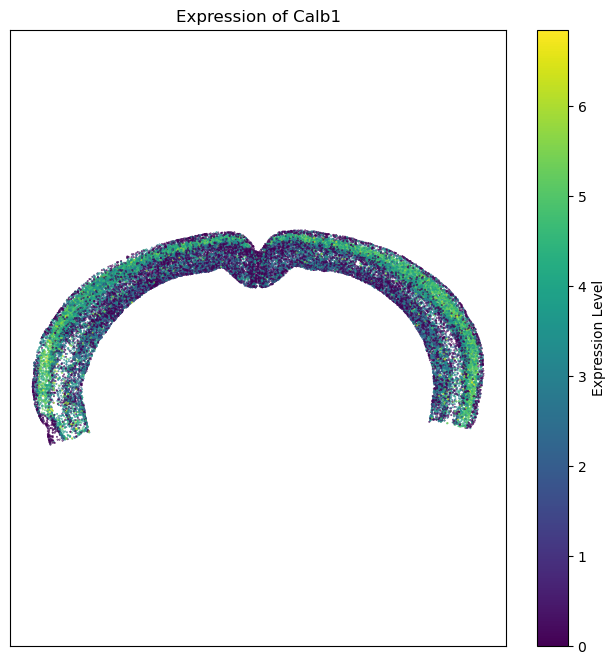

In [67]:
# Example usage:
gene_to_plot = list(overlap_dict['01 IT-ET Glut'])[5] # Replace with the gene you want to visualize
fig, ax = plot_gene_expression(isocortex_ad, gene_to_plot)
plt.show()

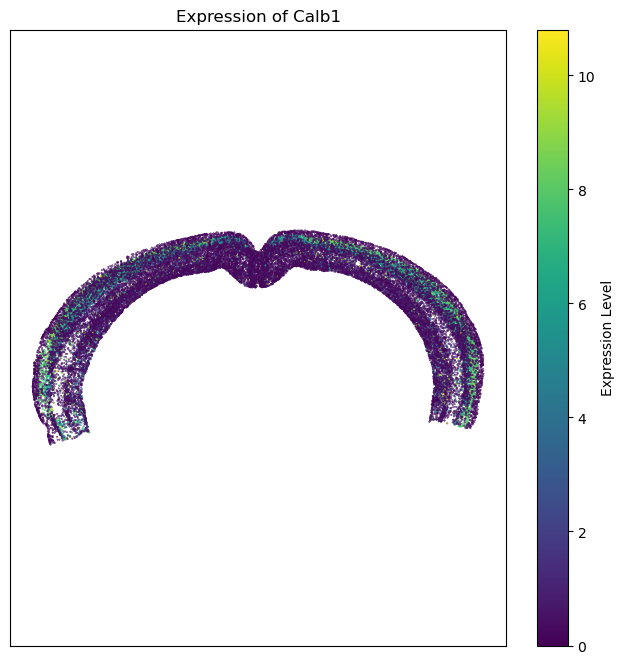

In [69]:
# Example usage:
gene_to_plot = list(overlap_dict['01 IT-ET Glut'])[5] # Replace with the gene you want to visualize
fig, ax = plot_gene_expression(isocortex_ad_imp, gene_to_plot)
plt.show()

In [45]:
isocortex_ad.obs['class'].value_counts()

class
01 IT-ET Glut        16366
02 NP-CT-L6b Glut     4977
30 Astro-Epen         4169
33 Vascular           4005
31 OPC-Oligo          2332
07 CTX-MGE GABA       1929
06 CTX-CGE GABA        977
34 Immune              620
08 CNU-MGE GABA         21
09 CNU-LGE GABA         15
13 CNU-HYa Glut         11
05 OB-IMN GABA           6
03 OB-CR Glut            5
11 CNU-HYa GABA          3
04 DG-IMN Glut           2
Name: count, dtype: int64